In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/16 - Copy - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/20.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/6 - Copy - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/6.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/9 - Copy - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/9 - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/13 - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/14 - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/9 - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/3 - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/15 - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/18 - Copy - Copy.jpg
/kaggle/input/datasets/inovasijb/datas

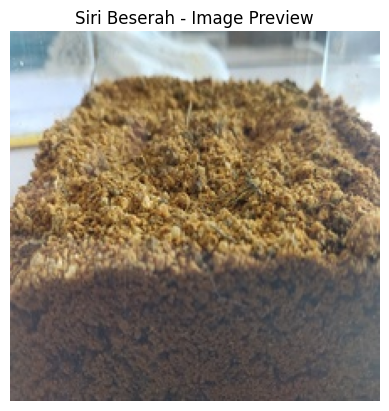

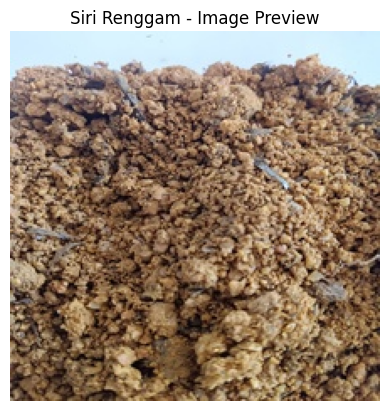

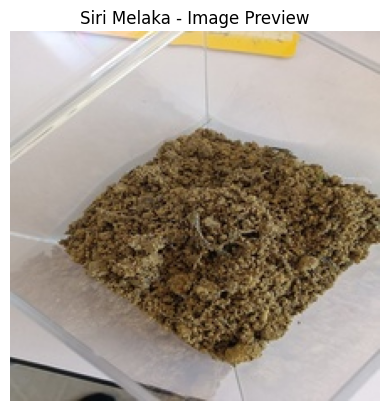

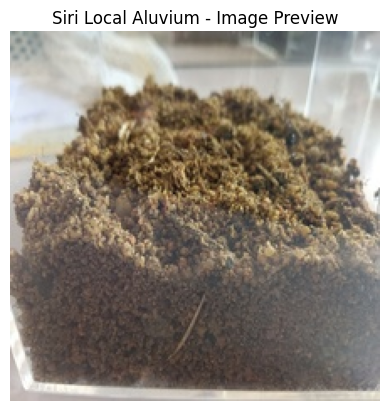

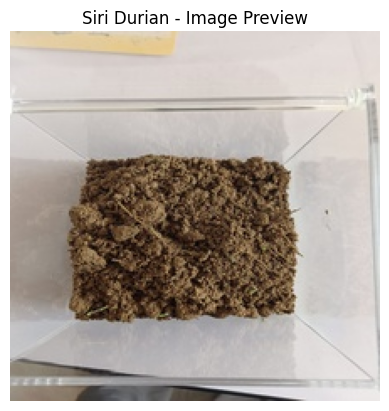

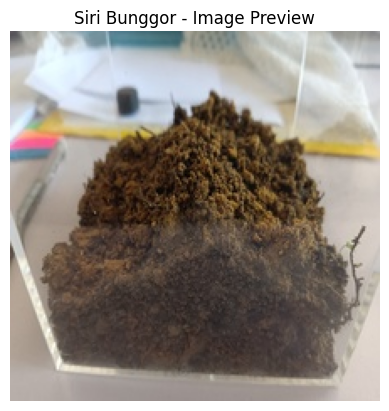

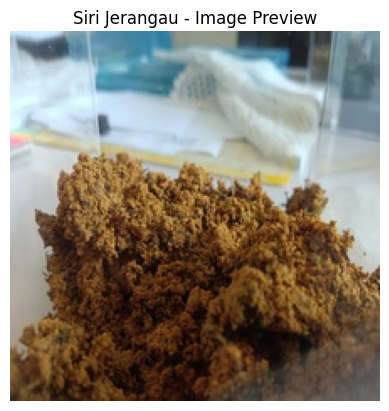

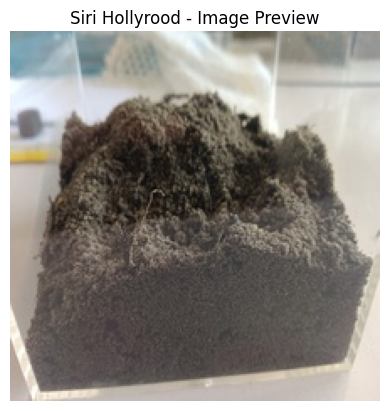

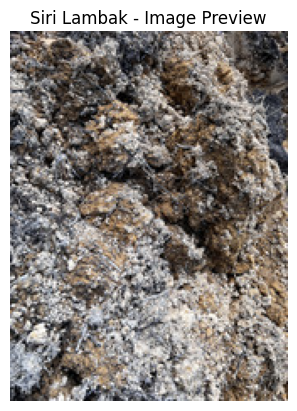

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_dir = "/kaggle/input/datasets/inovasijb/dataset/dataset/"

subfolders = os.listdir(data_dir)

for subfolder in subfolders:
    subfolder_path = os.path.join(data_dir, subfolder)
    
    image_files = [f for f in os.listdir(subfolder_path) if f.endswith(".jpg") or f.endswith(".png")]
    
    if image_files:
        image_path = os.path.join(subfolder_path, image_files[0])
        img = mpimg.imread(image_path)
        
        plt.imshow(img)
        plt.title(f"{subfolder} - Image Preview")
        plt.axis('off')
        plt.show()
    else:
        print(f"No images found in {subfolder}")

In [3]:
!pip3 install mahotas

  Obtaining dependency information for mahotas from https://files.pythonhosted.org/packages/54/1a/2f6dbb52599c9da9aac6da0f60950f6b7eed54a3d38779bf0f80d41b3eb9/mahotas-1.4.18-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 45.8 MB/s eta 0:00:0000:0100:01


In [4]:
import mahotas as mh
from skimage import color, feature, io

def extract_features(image_path):
    img = io.imread(image_path)
    gray_img = color.rgb2gray(img)  
    
    gray_img_int = (gray_img * 255).astype(np.uint8)
    
    haralick_features = mh.features.haralick(gray_img_int).mean(axis=0)
    
    hog_features, _ = feature.hog(gray_img, visualize=True)
    
    print("Haralick Features:", haralick_features[:5])
    print("HOG Features:", hog_features[:5])
    
    all_features = np.concatenate((haralick_features, hog_features))
    
    return all_features

image_path = '/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Beserah/1.jpg'
features = extract_features(image_path)
print("Extracted Features:", features)


Haralick Features: [7.35731038e-05 1.31264216e+03 6.15150190e-01 1.70545909e+03
 3.87589866e-02]
HOG Features: [0.06821046 0.01143533 0.07430607 0.06011967 0.07994475]
Extracted Features: [7.35731038e-05 1.31264216e+03 6.15150190e-01 ... 3.68642452e-02
 7.44878098e-02 1.05774532e-01]


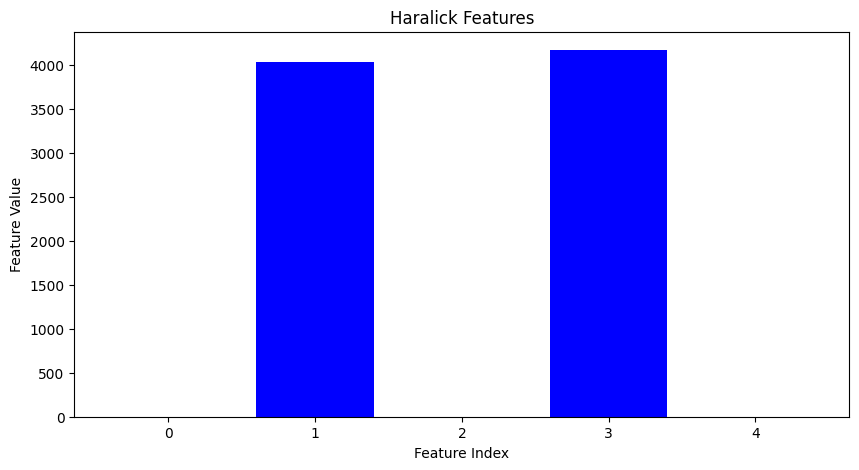

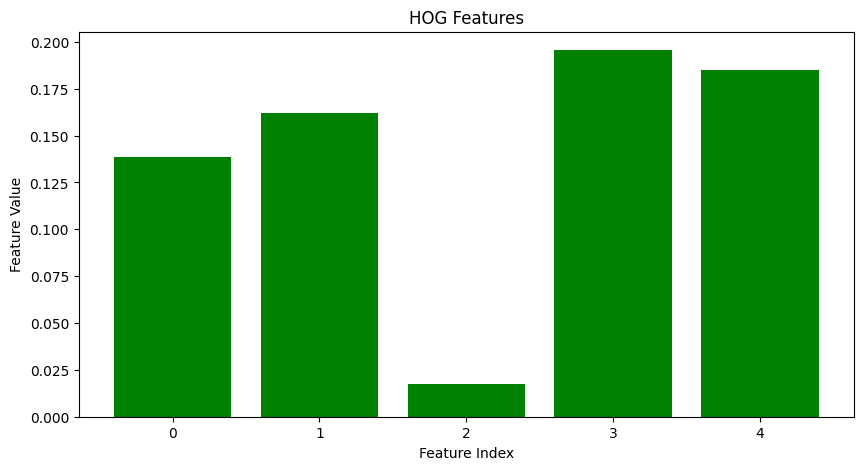

In [5]:
import matplotlib.pyplot as plt

# Extracted features
haralick_features = [6.01386001e-05, 4.03161950e+03, 5.16402659e-01, 4.16840819e+03, 3.56462429e-02]
hog_features = [0.13853615, 0.16210145, 0.01771583, 0.19563887, 0.18492717]

plt.figure(figsize=(10, 5))
plt.bar(range(len(haralick_features)), haralick_features, color='blue')
plt.title('Haralick Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(range(len(hog_features)), hog_features, color='green')
plt.title('HOG Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.show()


In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from skimage import color, feature, io
import mahotas as mh

def extract_features(image_path):
    img = io.imread(image_path)
    gray_img = color.rgb2gray(img)  # Convert image to grayscale
    gray_img_int = (gray_img * 255).astype(np.uint8)
    haralick_features = mh.features.haralick(gray_img_int).mean(axis=0)
    hog_features, _ = feature.hog(gray_img, visualize=True)
    hog_features_flat = hog_features.flatten()  # Flatten the HOG features
    # Ensure both sets of features have the same length
    hog_features_flat = hog_features_flat[:haralick_features.shape[0]]
    return np.concatenate((haralick_features, hog_features_flat))

data_dir = "/kaggle/input/datasets/inovasijb/dataset/dataset/"

image_paths = []
labels = []

class_indices = {'Siri Beserah': 0, 'Siri Bunggor': 1, 'Siri Durian': 2, 'Siri Hollyrood': 3, 'Siri Jerangau': 4, 'Siri Lambak': 5, 'Siri Local Aluvium': 6, 'Siri Melaka': 7, 'Siri Renggam': 8}

for soil_class, class_index in class_indices.items():
    class_dir = os.path.join(data_dir, soil_class)
    class_images = [os.path.join(class_dir, image) for image in os.listdir(class_dir)]
    image_paths.extend(class_images)
    labels.extend([class_index] * len(class_images))

X = [extract_features(image_path) for image_path in image_paths]

le = LabelEncoder()
y = le.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print("Random Forest Classifier:")
print("Accuracy:", accuracy_rf)
print("Classification Report:\n", report_rf)

Random Forest Classifier:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        17
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00        12
           7       1.00      1.00      1.00        12
           8       1.00      1.00      1.00        20

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

data_dir = "/kaggle/input/datasets/inovasijb/dataset/dataset/"

batch_size = 32 
image_size = (224, 224)

# ==========================================
# 1. LOAD DATASETS
# ==========================================
train_dataset = image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
)

validation_dataset = image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print("Class indices:", class_names)

# Optimize pipeline for Kaggle GPU performance (Prevents GPU starvation)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 2. DATA AUGMENTATION & PREPROCESSING
# ==========================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# ==========================================
# 3. BUILD TRANSFER LEARNING MODEL (MobileNetV2)
# ==========================================
# Load pre-trained MobileNetV2 without the top classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pre-trained weights

# MobileNetV2 specific preprocessing
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Build functional pipeline
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Replaces Flatten()
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# ==========================================
# 4. COMPILE MODEL
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 5. CALLBACKS
# ==========================================
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

# ==========================================
# 6. TRAIN MODEL
# ==========================================
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='model.h5',
    monitor='val_accuracy',       # Save based on best validation accuracy
    mode='max',
    save_best_only=True,          # Only overwrite if accuracy improves
    verbose=1
)

# Pass it into your callbacks list in model.fit()
epochs = 50
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr, checkpoint] # <--- Added here
)

Found 648 files belonging to 9 classes.
Using 519 files for training.
Found 648 files belonging to 9 classes.
Using 129 files for validation.
Class indices: ['Siri Beserah', 'Siri Bunggor', 'Siri Durian', 'Siri Hollyrood', 'Siri Jerangau', 'Siri Lambak', 'Siri Local Aluvium', 'Siri Melaka', 'Siri Renggam']
9406464/9406464 [==============================] - 0s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv (TFOpLambd  (None, 224, 224, 3)       0         
 a)                                                              
                                                                 
 tf.math.subtract (T

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


17/17 [==============================] - ETA: 0s - loss: 1.9685 - accuracy: 0.2909
Epoch 2: val_accuracy improved from 0.34884 to 0.43411, saving model to model.h5
17/17 [==============================] - 10s 614ms/step - loss: 1.9685 - accuracy: 0.2909 - val_loss: 1.5569 - val_accuracy: 0.4341 - lr: 0.0010
Epoch 3/50
17/17 [==============================] - ETA: 0s - loss: 1.5687 - accuracy: 0.4316
Epoch 3: val_accuracy improved from 0.43411 to 0.51163, saving model to model.h5
17/17 [==============================] - 10s 618ms/step - loss: 1.5687 - accuracy: 0.4316 - val_loss: 1.3580 - val_accuracy: 0.5116 - lr: 0.0010
Epoch 4/50
17/17 [==============================] - ETA: 0s - loss: 1.3775 - accuracy: 0.5299
Epoch 4: val_accuracy improved from 0.51163 to 0.62791, saving model to model.h5
17/17 [==============================] - 10s 623ms/step - loss: 1.3775 - accuracy: 0.5299 - val_loss: 1.1633 - val_accuracy: 0.6279 - lr: 0.0010
Epoch 5/50
17/17 [==============================] -

In [8]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Ensure image_size is defined
image_size = (224, 224)

def load_and_preprocess_image(img_path):
    # Load image at correct target size
    img = image.load_img(img_path, target_size=image_size)
    img_array = image.img_to_array(img)
    
    # Expand dims to create batch shape: (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)
    
    # DO NOT divide by 255.0! 
    # MobileNetV2's preprocess_input layer inside the model handles raw [0, 255] pixels.
    return img_array

# Test image path
image_path = '/kaggle/input/datasets/inovasijb/dataset/dataset/Siri Melaka/5.jpg'
new_image = load_and_preprocess_image(image_path)

# Predict
predictions = model.predict(new_image)
predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

class_labels = {
    0: 'Siri Beserah', 1: 'Siri Bunggor', 2: 'Siri Durian', 
    3: 'Siri Hollyrood', 4: 'Siri Jerangau', 5: 'Siri Lambak', 
    6: 'Siri Local Aluvium', 7: 'Siri Melaka', 8: 'Siri Renggam'
}

predicted_label = class_labels[predicted_class]

print(f"Predicted Class Index: {predicted_class}")
print(f"Predicted Label: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")

1/1 [==============================] - 1s 932ms/step
Predicted Class Index: 7
Predicted Label: Siri Melaka
Confidence: 96.10%


In [9]:
base_classifiers = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='rbf', C=1.0, probability=True)),
    ('nb', GaussianNB())
]

stacking_classifier = StackingClassifier(estimators=base_classifiers, final_estimator=LogisticRegression())

stacking_classifier.fit(X_train, y_train)

y_pred_stacking = stacking_classifier.predict(X_test)

accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
report_stacking = classification_report(y_test, y_pred_stacking)

print("\nStacking Classifier:")
print("Accuracy:", accuracy_stacking)
print("Classification Report:\n", report_stacking)


Stacking Classifier:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        17
           5       1.00      1.00      1.00         6
           6       1.00      1.00      1.00        12
           7       1.00      1.00      1.00        12
           8       1.00      1.00      1.00        20

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



In [10]:
import tensorflow as tf

# 1. Load your existing Keras model
model = tf.keras.models.load_model('model.h5')

# 2. Initialize the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Apply post-training quantization to drastically reduce file size
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4. Convert the model to flatbuffer format
tflite_quant_model = converter.convert()

# 5. Save the smaller .tflite model file
with open('model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("Quantized TFLite model successfully saved.")

Quantized TFLite model successfully saved.


In [11]:
import os

h5_size = os.path.getsize('model.h5') / (1024 * 1024)
tflite_size = os.path.getsize('model.tflite') / (1024 * 1024)

print(f"Original H5 Size: {h5_size:.2f} MB")
print(f"Optimized TFLite Size: {tflite_size:.2f} MB")


Original H5 Size: 9.07 MB
Optimized TFLite Size: 2.40 MB


In [12]:
from IPython.display import FileLink

# Replace 'my_output.csv' with your actual filename
FileLink(r'model.tflite')

/kaggle/working/model.tflite

In [13]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_1 = user_secrets.get_secret("GITHUB_TOKEN")

!git config --global user.name "inovasijb"
!git config --global user.email "inovasijbwiralestari@gmail.com"

# Clone repo
!git clone https://{secret_value_1}@github.com/inovasijb/wsl.git

# Copy updated model file
!cp model.tflite wsl/assets/

# Add, commit, and push using git -C to target the wsl folder
!git -C wsl add assets/model.tflite
!git -C wsl commit -m "Push updated model.tflite from kaggle"
!git -C wsl push https://{secret_value_1}@github.com/inovasijb/wsl.git main

Cloning into 'wsl'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 77 (delta 8), reused 3 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (77/77), 22.15 MiB | 8.78 MiB/s, done.
[main a6026d5] Push updated model.tflite from kaggle
 1 file changed, 0 insertions(+), 0 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 57.93 KiB | 1.41 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0)
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/inovasijb/wsl.git
   29062d4..a6026d5  main -> main
